# Agent Orchestration: Collaborative Research Team (Evaluator-Optimizer)

In business, the first draft is rarely the final draft. In this notebook, we master the **Evaluator-Optimizer** pattern—a feedback loop where one agent creates and another agent improves the work.

## 1. How the Loop Works
1. **Optimizer (The Generator)**: Writes the initial content based on a prompt.
2. **Evaluator (The Critic)**: Reviews the content against specific criteria (Accuracy, Tone, Formatting).
3. **Iterate**: If the Evaluator finds flaws, the Optimizer rewrites the content based on the feedback.
4. **Exit**: The loop ends when the Evaluator gives a "Pass" or a maximum number of revisions is reached.

---

## 2. Environment Setup
We use Gemini 2.5 Flash. We'll set a higher temperature for the Optimizer (creativity) and a lower temperature for the Evaluator (precision).

In [7]:
import os
from typing import Annotated, TypedDict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
optimizer_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)
evaluator_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Research Team Loop Ready!")

Research Team Loop Ready!


## 3. Defining the Team State
We add a `revision_count` to track how many times the draft has been fixed.

In [2]:
class TeamState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    revision_count: int
    is_approved: bool

## 4. Defining the Evaluator Model
The evaluator must give a clear "Approve" or "Reject" decision.

In [3]:
class Evaluation(BaseModel):
    """Grade the quality of the report."""
    feedback: str = Field(description="Constructive feedback for the writer.")
    is_approved: bool = Field(description="True if the report meets all quality standards.")

critic_llm = evaluator_llm.with_structured_output(Evaluation)

## 5. Defining the Nodes
The optimizer generates/rewrites, and the evaluator critiques.

In [4]:
def optimizer_node(state: TeamState):
    system_msg = SystemMessage(content="""You are a technical writer. Create a concise summary of the topic. 
                               If you have received feedback, use it to improve your previous draft.""")
    response = optimizer_llm.invoke([system_msg] + state["messages"])
    # Increment revision count in the state update
    return {
        "messages": [AIMessage(content=response.content, name="Writer")],
        "revision_count": state.get("revision_count", 0) + 1
    }

def evaluator_node(state: TeamState):
    system_msg = SystemMessage(content="""You are a strict technical editor. 
                               Review the latest draft for clarity and technical accuracy.
                               If it is excellent, set is_approved to True.""")
    # The evaluator looks only at the conversation
    result = critic_llm.invoke([system_msg] + state["messages"])
    
    # We wrap the boolean decision in a message so the Writer can see the feedback
    feedback_msg = AIMessage(
        content=f"Evaluation Result: {result.is_approved}\nFeedback: {result.feedback}", 
        name="Critic"
    )
    
    return {"messages": [feedback_msg], "is_approved": result.is_approved}

def should_continue(state: TeamState):
    # Check the custom 'is_approved' flag from the state OR the revision count
    if state.get("is_approved", False) or state.get("revision_count", 0) >= 3:
        return END
    return "optimizer"

## 6. Building & Visualizing the Feedback Graph
This graph contains a **Cycle** (a circle in the logic). Visualizing this is critical for understanding the loop.

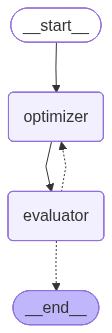

In [5]:
workflow = StateGraph(TeamState)

workflow.add_node("optimizer", optimizer_node)
workflow.add_node("evaluator", evaluator_node)

workflow.add_edge(START, "optimizer")
workflow.add_edge("optimizer", "evaluator")

workflow.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "optimizer": "optimizer",
        END: END
    }
)

app = workflow.compile()

# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Visualization failed.")

## 7. Running the Iterative Team
We'll watch the agents collaborate through multiple revisions.

In [6]:
query = "Describe how a jet engine works in 3 complex sentences."
initial_state = {"messages": [HumanMessage(content=query)], "revision_count": 0}

for chunk in app.stream(initial_state, stream_mode="values"):
    messages = chunk["messages"]
    if messages:
        last_msg = messages[-1]
        if hasattr(last_msg, "name") and last_msg.name:
            print(f"\n--- {last_msg.name} (Rev {chunk.get('revision_count', 0)}) ---")
            print(last_msg.content)


--- Writer (Rev 1) ---
A jet engine operates by drawing in ambient air through an inlet, where a fan and subsequent compressor stages rapidly pressurize it, significantly increasing its density and temperature. This highly compressed air is then mixed with fuel in the combustor, igniting to produce a superheated, high-velocity gas stream whose expansion generates immense energy. Finally, this powerful gas stream propels through a turbine, which extracts energy to drive the compressor before exiting a nozzle at extreme speed, thereby creating forward thrust according to Newton's third law.

--- Critic (Rev 1) ---
Evaluation Result: True
Feedback: The description is technically accurate and uses complex sentences as requested. It clearly explains the three main stages of a jet engine's operation.


## 8. Summary & Pro-Tips
1. **Infinite Loops**: Always set a `revision_count` or a time limit. LLMs can sometimes get stuck arguing about small details forever.
2. **Specialized Prompts**: Note how the Evaluator has `temperature=0`. You want your critics to be consistent and your writers to be creative.
3. **Human-in-the-loop**: You can add a node between the Evaluator and Optimizer that pauses for a human to approve the revision before it continues.

---